# Module 4: Sales Forecasting

## NovaMart AI Retail Intelligence Platform

### Overview

Sales forecasting is a fundamental component of retail analytics. Accurate demand prediction enables businesses to optimize inventory levels, improve procurement planning, allocate resources efficiently, and maximize profitability.

This notebook develops machine learning models capable of forecasting future monthly sales revenue using historical transaction data from the NovaMart retail platform.

Historical order information is transformed into a time-series dataset, followed by feature engineering, model development, performance evaluation, and future revenue forecasting.

### Objectives

The objectives of this notebook are to:

- Build a monthly sales forecasting dataset.
- Explore historical revenue trends.
- Engineer temporal and lag-based features.
- Develop machine learning forecasting models.
- Compare forecasting performance.
- Forecast future monthly sales.
- Generate business insights for inventory planning and decision-making.

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load the Master Dataset

The integrated retail dataset produced during the data acquisition and feature engineering stages is loaded for forecasting.

In [2]:
retail = pd.read_csv("retail_master_dataset.csv")

In [3]:
retail.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,geolocation_zip_code_prefix,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,5.0,NaN,"Perfeito, produto entregue antes do combinado.",28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,-22.497188,-44.127324,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,4.0,NaN,NaN,15775.0,-20.222506,-50.898951,santa fe do sul,SP,-23.565754,-46.519097,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,35661.0,-19.869998,-44.593059,para de minas,MG,-22.262802,-46.170735,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,25.78,2.0,credit_card,4.0,NaN,NaN,12952.0,-23.105968,-46.590277,atibaia,SP,-20.553651,-47.387145,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,5.0,NaN,Gostei pois veio no prazo determinado .,13226.0,-23.243402,-46.827614,varzea paulista,SP,-22.929583,-53.135750,loanda,PR


### Convert Dates to DateTime

In [5]:
date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_customer_date",

    "order_estimated_delivery_date"

]

for col in date_columns:

    retail[col] = pd.to_datetime(retail[col])

### Dataset Overview

In [6]:
retail.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,geolocation_zip_code_prefix,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,5.0,NaN,"Perfeito, produto entregue antes do combinado.",28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,-22.497188,-44.127324,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,4.0,NaN,NaN,15775.0,-20.222506,-50.898951,santa fe do sul,SP,-23.565754,-46.519097,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,35661.0,-19.869998,-44.593059,para de minas,MG,-22.262802,-46.170735,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,25.78,2.0,credit_card,4.0,NaN,NaN,12952.0,-23.105968,-46.590277,atibaia,SP,-20.553651,-47.387145,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,5.0,NaN,Gostei pois veio no prazo determinado .,13226.0,-23.243402,-46.827614,varzea paulista,SP,-22.929583,-53.135750,loanda,PR


In [7]:
retail.shape

(113049, 46)

In [8]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113049 entries, 0 to 113048
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113049 non-null  object        
 1   order_item_id                  113049 non-null  int64         
 2   product_id                     113049 non-null  object        
 3   seller_id                      113049 non-null  object        
 4   shipping_limit_date            113049 non-null  object        
 5   price                          113049 non-null  float64       
 6   freight_value                  113049 non-null  float64       
 7   customer_id                    113049 non-null  object        
 8   order_status                   113049 non-null  object        
 9   order_purchase_timestamp       113049 non-null  datetime64[ns]
 10  order_approved_at              113034 non-null  datetime64[ns]
 11  

## Aggregate Monthly Sales

Monthly revenue is computed by summing the payment value of all completed orders within each calendar month.

In [9]:
monthly_sales = (

    retail

    .groupby(

        pd.Grouper(

            key="order_purchase_timestamp",

            freq="M"

        )

    )["payment_value"]

    .sum()

    .reset_index()

)

monthly_sales.columns = [

    "Month",

    "Revenue"

]

monthly_sales.head()

,Month,Revenue
0,2016-09-30,347.52
1,2016-10-31,74353.46
2,2016-11-30,0.00
3,2016-12-31,19.62
4,2017-01-31,187865.53


### The September 2018 records are incomplete and therefore excluded from forecasting.

In [10]:
monthly_sales = monthly_sales[
    monthly_sales["Month"] < "2018-09-01"
]

### Time Series Overview

In [11]:
#Time Series Overview
monthly_sales

,Month,Revenue
0,2016-09-30,347.52
1,2016-10-31,74353.46
2,2016-11-30,0.00
3,2016-12-31,19.62
4,2017-01-31,187865.53
5,2017-02-28,345640.05
6,2017-03-31,529374.98
7,2017-04-30,506438.53
8,2017-05-31,727529.51
9,2017-06-30,603246.83


### Revenue Trend

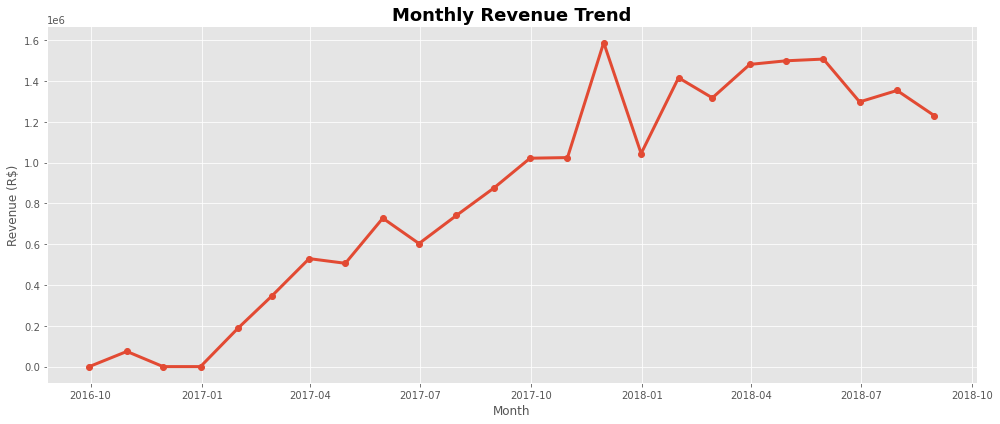

In [12]:
# Revenue Trend
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales["Month"],

    monthly_sales["Revenue"],

    marker="o",

    linewidth=3

)

plt.title(

    "Monthly Revenue Trend",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Month")

plt.ylabel("Revenue (R$)")

plt.grid(True)

plt.tight_layout()

plt.show()

## Rolling Average

A three-month moving average is calculated to smooth short-term fluctuations and highlight longer-term trends.

In [13]:
monthly_sales["Rolling_Mean"] = (

    monthly_sales["Revenue"]

    .rolling(3)

    .mean()

)

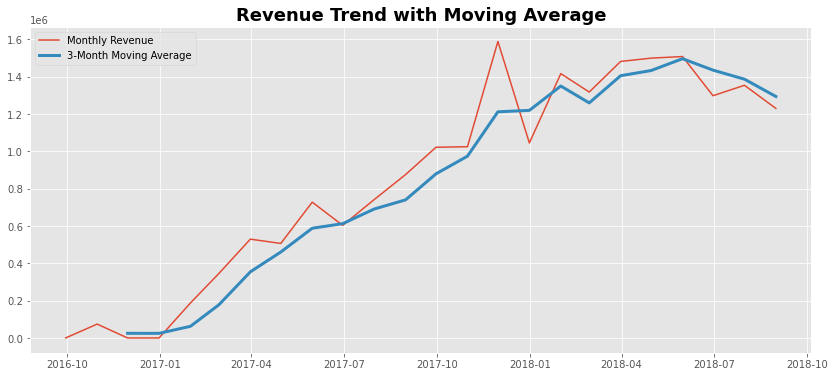

In [14]:
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales["Month"],

    monthly_sales["Revenue"],

    label="Monthly Revenue"

)

plt.plot(

    monthly_sales["Month"],

    monthly_sales["Rolling_Mean"],

    linewidth=3,

    label="3-Month Moving Average"

)

plt.legend()

plt.title(

    "Revenue Trend with Moving Average",

    fontsize=18,

    fontweight="bold"

)

plt.show()

### Monthly Growth Rate

In [21]:
growth = monthly_sales.iloc[3:].copy()

growth["Growth_Rate"] = (
    growth["Revenue"]
    .pct_change()
    .mul(100)
)

growth = growth.replace([np.inf, -np.inf], np.nan)

In [22]:
growth.round(2)

,Month,Revenue,Rolling_Mean,Growth_Rate
3,2016-12-31,19.62,24791.03,NaN
4,2017-01-31,187865.53,62628.38,957420.54
5,2017-02-28,345640.05,177841.73,83.98
6,2017-03-31,529374.98,354293.52,53.16
7,2017-04-30,506438.53,460484.52,-4.33
8,2017-05-31,727529.51,587781.01,43.66
9,2017-06-30,603246.83,612404.96,-17.08
10,2017-07-31,741082.99,690619.78,22.85
11,2017-08-31,875353.41,739894.41,18.12
12,2017-09-30,1021634.94,879357.11,16.71


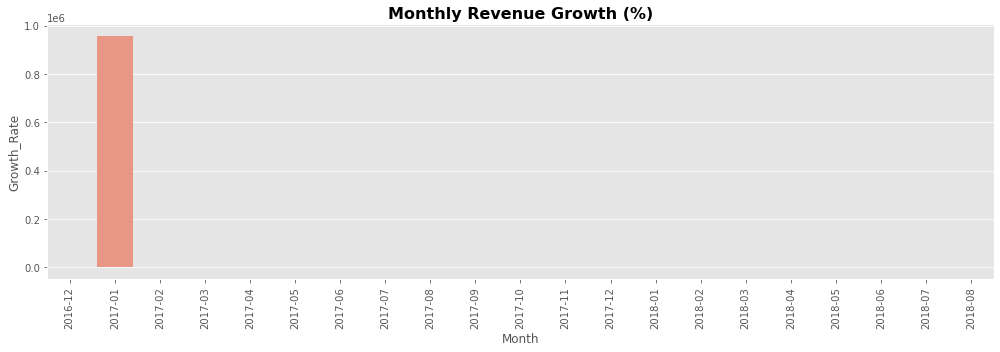

In [23]:
plt.figure(figsize=(14,5))

sns.barplot(

    x=growth["Month"].dt.strftime("%Y-%m"),

    y=growth["Growth_Rate"]

)

plt.xticks(rotation=90)

plt.title(

    "Monthly Revenue Growth (%)",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## Interpretation

The initial months of the dataset exhibit extremely large percentage changes because the marketplace was newly established and monthly revenue was very low. Small absolute increases in revenue therefore translate into disproportionately large percentage growth rates. To obtain a more meaningful representation of business performance, infinite and undefined growth values were removed before visualization, and the subsequent analysis focuses on periods with stable transaction volumes.

# Time-Series Feature Engineering

Machine learning models cannot directly interpret dates. Therefore, temporal features are extracted from the monthly sales data to capture seasonality and long-term trends.

The following features are created:

- Year
- Month
- Quarter
- Lag Features
- Rolling Statistics

In [24]:
monthly_sales

,Month,Revenue,Rolling_Mean,Growth_Rate
0,2016-09-30,347.52,NaN,NaN
1,2016-10-31,74353.46,NaN,21295.447744
2,2016-11-30,0.00,2.490033e+04,-100.000000
3,2016-12-31,19.62,2.479103e+04,NaN
4,2017-01-31,187865.53,6.262838e+04,957420.540265
5,2017-02-28,345640.05,1.778417e+05,83.982687
6,2017-03-31,529374.98,3.542935e+05,53.157882
7,2017-04-30,506438.53,4.604845e+05,-4.332742
8,2017-05-31,727529.51,5.877810e+05,43.656035
9,2017-06-30,603246.83,6.124050e+05,-17.082837


In [25]:
# ==========================================================
# Calendar Features
# ==========================================================

monthly_sales["Year"] = monthly_sales["Month"].dt.year

monthly_sales["Month_Number"] = monthly_sales["Month"].dt.month

monthly_sales["Quarter"] = monthly_sales["Month"].dt.quarter

monthly_sales.head()

,Month,Revenue,Rolling_Mean,Growth_Rate,Year,Month_Number,Quarter
0,2016-09-30,347.52,NaN,NaN,2016,9,3
1,2016-10-31,74353.46,NaN,21295.447744,2016,10,4
2,2016-11-30,0.00,24900.326667,-100.000000,2016,11,4
3,2016-12-31,19.62,24791.026667,NaN,2016,12,4
4,2017-01-31,187865.53,62628.383333,957420.540265,2017,1,1


## Lag Features

Lag variables allow the forecasting model to learn from previous months' revenue.

For example:

- Lag 1 = Previous month's revenue
- Lag 2 = Revenue two months ago
- Lag 3 = Revenue three months ago
- Lag 6 = Revenue six months ago

In [26]:
# ==========================================================
# Lag Features
# ==========================================================

monthly_sales["Lag_1"] = monthly_sales["Revenue"].shift(1)

monthly_sales["Lag_2"] = monthly_sales["Revenue"].shift(2)

monthly_sales["Lag_3"] = monthly_sales["Revenue"].shift(3)

monthly_sales["Lag_6"] = monthly_sales["Revenue"].shift(6)

In [28]:
monthly_sales.head()

,Month,Revenue,Rolling_Mean,Growth_Rate,Year,Month_Number,Quarter,Lag_1,Lag_2,Lag_3,Lag_6
0,2016-09-30,347.52,NaN,NaN,2016,9,3,NaN,NaN,NaN,NaN
1,2016-10-31,74353.46,NaN,21295.447744,2016,10,4,347.52,NaN,NaN,NaN
2,2016-11-30,0.00,24900.326667,-100.000000,2016,11,4,74353.46,347.52,NaN,NaN
3,2016-12-31,19.62,24791.026667,NaN,2016,12,4,0.00,74353.46,347.52,NaN
4,2017-01-31,187865.53,62628.383333,957420.540265,2017,1,1,19.62,0.00,74353.46,NaN


## Rolling Window Features

Rolling statistics summarize recent sales behaviour and help the model capture local trends.

Features include:

- Rolling Mean
- Rolling Standard Deviation

In [29]:
monthly_sales["Rolling_Mean_3"] = (
    monthly_sales["Revenue"]
    .rolling(3)
    .mean()
)

monthly_sales["Rolling_STD_3"] = (
    monthly_sales["Revenue"]
    .rolling(3)
    .std()
)

### Check Missing Values

In [30]:
#Check Missing Values
monthly_sales.isnull().sum()

Month             0
Revenue           0
Rolling_Mean      2
Growth_Rate       2
Year              0
Month_Number      0
Quarter           0
Lag_1             1
Lag_2             2
Lag_3             3
Lag_6             6
Rolling_Mean_3    2
Rolling_STD_3     2
dtype: int64

### Remove Missing Rows

In [31]:
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

monthly_sales.head()

,Month,Revenue,Rolling_Mean,Growth_Rate,Year,Month_Number,Quarter,Lag_1,Lag_2,Lag_3,Lag_6,Rolling_Mean_3,Rolling_STD_3
0,2017-03-31,529374.98,354293.520000,53.157882,2017,3,1,345640.05,187865.53,19.62,347.52,354293.520000,170919.097871
1,2017-04-30,506438.53,460484.520000,-4.332742,2017,4,2,529374.98,345640.05,187865.53,74353.46,460484.520000,100117.228297
2,2017-05-31,727529.51,587781.006667,43.656035,2017,5,2,506438.53,529374.98,345640.05,0.00,587781.006667,121567.895937
3,2017-06-30,603246.83,612404.956667,-17.082837,2017,6,2,727529.51,506438.53,529374.98,19.62,612404.956667,110829.638736
4,2017-07-31,741082.99,690619.776667,22.849048,2017,7,3,603246.83,727529.51,506438.53,187865.53,690619.776667,75970.047137


In [32]:
#Check Missing Values
monthly_sales.isnull().sum()

Month             0
Revenue           0
Rolling_Mean      0
Growth_Rate       0
Year              0
Month_Number      0
Quarter           0
Lag_1             0
Lag_2             0
Lag_3             0
Lag_6             0
Rolling_Mean_3    0
Rolling_STD_3     0
dtype: int64

In [34]:
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Month           18 non-null     datetime64[ns]
 1   Revenue         18 non-null     float64       
 2   Rolling_Mean    18 non-null     float64       
 3   Growth_Rate     18 non-null     float64       
 4   Year            18 non-null     int64         
 5   Month_Number    18 non-null     int64         
 6   Quarter         18 non-null     int64         
 7   Lag_1           18 non-null     float64       
 8   Lag_2           18 non-null     float64       
 9   Lag_3           18 non-null     float64       
 10  Lag_6           18 non-null     float64       
 11  Rolling_Mean_3  18 non-null     float64       
 12  Rolling_STD_3   18 non-null     float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 2.0 KB


## Feature Correlation

The engineered features are examined to understand their relationships with monthly revenue.

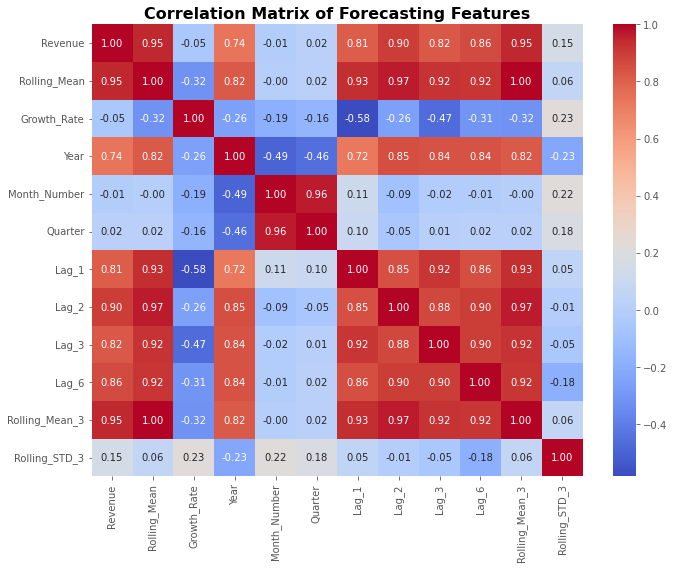

In [35]:
# Select only numeric columns
corr_matrix = monthly_sales.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Forecasting Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Prepare Machine Learning Dataset

In [36]:
X = monthly_sales[

    [

        "Year",

        "Month_Number",

        "Quarter",

        "Lag_1",

        "Lag_2",

        "Lag_3",

        "Lag_6",

        "Rolling_Mean_3",

        "Rolling_STD_3"

    ]

]

y = monthly_sales["Revenue"]

In [37]:
print("Feature Matrix:", X.shape)

print("Target Variable:", y.shape)

Feature Matrix: (18, 9)
Target Variable: (18,)


## Train-Test Split

Unlike traditional machine learning problems, time-series data must preserve chronological order.

The earliest observations are used for training, while the most recent observations are reserved for testing.

In [41]:
split_index = int(len(monthly_sales) * 0.80)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [42]:
X_train.shape

(14, 9)

In [43]:
X_test.shape

(4, 9)

In [44]:
print("Training Samples :", len(X_train))

print("Testing Samples  :", len(X_test))

Training Samples : 14
Testing Samples  : 4


## Baseline Forecast

A persistence model is used as a simple baseline. It predicts that the next month's revenue will be equal to the previous month's revenue.

In [45]:
baseline_predictions = X_test["Lag_1"]

### Baseline Performance

In [46]:
baseline_mae = mean_absolute_error(

    y_test,

    baseline_predictions

)

baseline_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        baseline_predictions

    )

)

print("Baseline MAE :", round(baseline_mae,2))

print("Baseline RMSE:", round(baseline_rmse,2))

Baseline MAE : 99608.62
Baseline RMSE: 125158.96


## Random Forest Regressor

A Random Forest Regressor is trained to predict monthly revenue using engineered temporal features.

Random Forest is selected because it can model nonlinear relationships and interactions without requiring strict assumptions about the underlying data.

In [47]:
rf = RandomForestRegressor(

    n_estimators=300,

    random_state=42,

    max_depth=6

)

rf.fit(

    X_train,

    y_train

)

RandomForestRegressor(max_depth=6, n_estimators=300, random_state=42)

### Predictions

In [49]:
rf_predictions = rf.predict(X_test)

#### Model Evaluation

In [50]:
mae = mean_absolute_error(

    y_test,

    rf_predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_predictions

    )

)

r2 = r2_score(

    y_test,

    rf_predictions

)

mape = (

    np.mean(

        np.abs(

            (y_test-rf_predictions)/y_test

        )

    )

    *100

)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

print(f"MAPE : {mape:.2f}%")

MAE  : 125943.64
RMSE : 140938.75
R²   : -0.8902
MAPE : 9.74%


### Compare Actual and Predicted Revenue

In [51]:
#Compare Actual and Predicted Revenue
forecast_results = pd.DataFrame({

    "Month": monthly_sales.iloc[split_index:]["Month"],

    "Actual": y_test.values,

    "Predicted": rf_predictions

})

forecast_results

,Month,Actual,Predicted
14,2018-05-31,1507629.78,1.464506e+06
15,2018-06-30,1297707.51,1.461549e+06
16,2018-07-31,1353727.22,1.444238e+06
17,2018-08-31,1229703.97,1.436003e+06


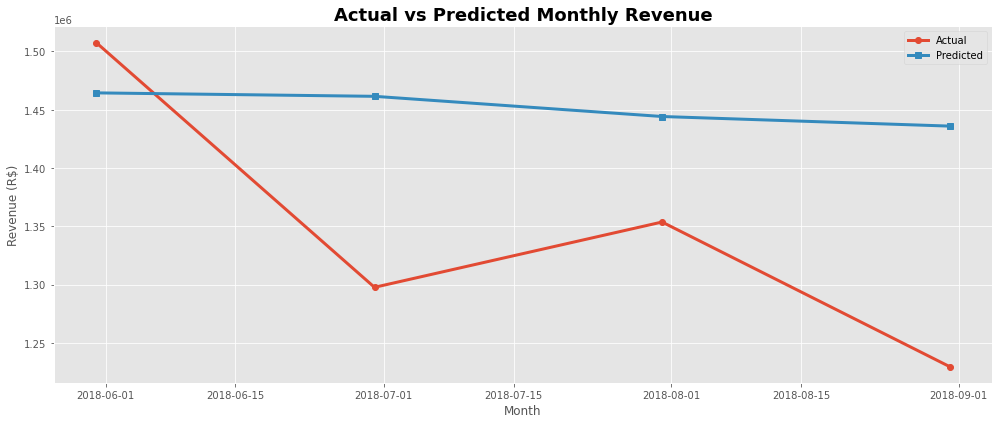

In [52]:
plt.figure(figsize=(14,6))

plt.plot(

    forecast_results["Month"],

    forecast_results["Actual"],

    marker="o",

    linewidth=3,

    label="Actual"

)

plt.plot(

    forecast_results["Month"],

    forecast_results["Predicted"],

    marker="s",

    linewidth=3,

    label="Predicted"

)

plt.title(

    "Actual vs Predicted Monthly Revenue",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Month")

plt.ylabel("Revenue (R$)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [53]:
daily_sales = (
    retail
    .groupby(pd.Grouper(
        key="order_purchase_timestamp",
        freq="D"
    ))["payment_value"]
    .sum()
    .reset_index()
)

In [ ]:
daily_sales = (
    retail
    .groupby(pd.Grouper(
        key="order_purchase_timestamp",
        freq="D"
    ))["payment_value"]
    .sum()
    .reset_index()
)